<a href="https://colab.research.google.com/github/Deyanet001/Machine-Learning-Projects/blob/main/Logistic_R_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#!/bin/bash
!curl -L -o titanic-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/yasserh/titanic-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 22564  100 22564    0     0  45153      0 --:--:-- --:--:-- --:--:--  524k


In [3]:
!unzip /content/titanic-dataset.zip

Archive:  /content/titanic-dataset.zip
  inflating: Titanic-Dataset.csv     


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [8]:
df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'], inplace=True)

In [9]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_505/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [10]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_505/3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1
887,1,1,female,19.0,0,0,30.0000,S,1
888,0,3,female,28.0,1,2,23.4500,S,4
889,1,1,male,26.0,0,0,30.0000,C,1


In [12]:
df['IsAlone'] = (df['FamilySize'] ==1).astype(int)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1,1
887,1,1,female,19.0,0,0,30.0000,S,1,1
888,0,3,female,28.0,1,2,23.4500,S,4,0
889,1,1,male,26.0,0,0,30.0000,C,1,1


In [13]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [14]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,0,True,False,True
1,1,1,38.0,1,0,71.2833,2,0,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,True
3,1,1,35.0,1,0,53.1000,2,0,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1,1,True,False,True
887,1,1,19.0,0,0,30.0000,1,1,False,False,True
888,0,3,28.0,1,2,23.4500,4,0,False,False,True
889,1,1,26.0,0,0,30.0000,1,1,True,False,False


In [15]:
X = df.drop('Survived', axis = 1)
y = df['Survived']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state=42, stratify = y
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 100, class_weight = 'balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [30]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[90 20]
 [17 52]]


In [31]:
# 1 - cekiler tesadufi secilir
# 2 - p ehtimali tapir
# 3 - loss hesablayir
# 4 - gradient hesablanir
# 5 - cekileri yenileyir
# 6 - loss azalir
# 7 - loss-u minimuma catdirmaga calisir

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Prediction
y_pred = model.predict(X_test)

# Scores
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


# Full report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7932960893854749
Precision: 0.7222222222222222
Recall: 0.7536231884057971
F1 Score: 0.7375886524822695
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       110
           1       0.72      0.75      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.80      0.79      0.79       179



Confusion Matrix:


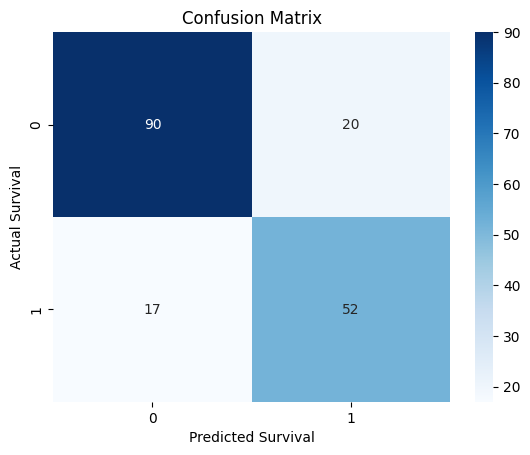

In [33]:
import seaborn as sns
# Confusion Matrix
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=df['Survived'].unique(),
    yticklabels=df['Survived'].unique()
    )
plt.title("Confusion Matrix")
plt.xlabel("Predicted Survival")
plt.ylabel("Actual Survival")
plt.show()


In [34]:
from sklearn.metrics import roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8507246376811595


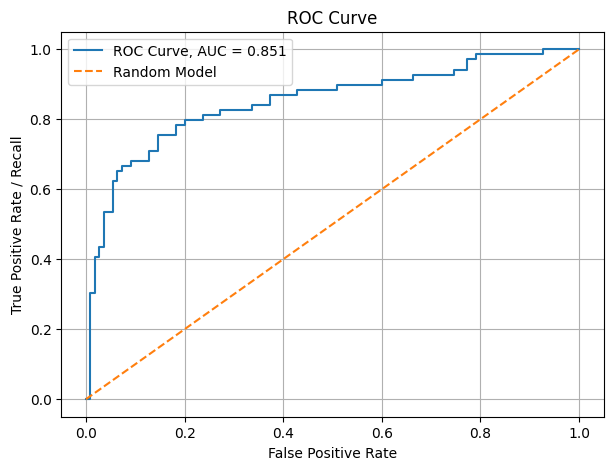

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve üçün dəyərlər
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# AUC hesablanır
roc_auc = auc(fpr, tpr)

# Vizualizasiya
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve, AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

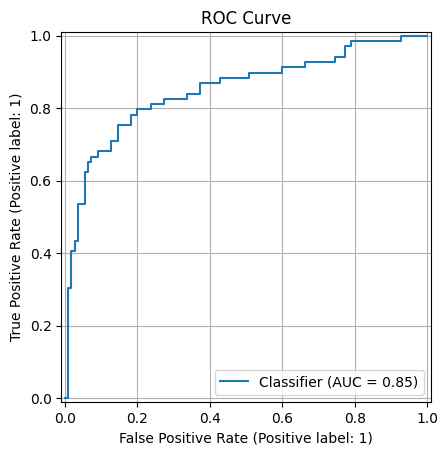

In [36]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.grid()
plt.show()